# Demo 2: Controlled Pendulum
## Demo 2.8: Update SysSimX

- **Connections**

- **System**

- **Resolving Computational Causality**

- **System Graph Creation**

In [38]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from docs.plot_setup import set_professional_style
plt = set_professional_style()

**Generate FMUComponents**

In [39]:
from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent

demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

fmu_paths

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


{'AngleEncoder': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu'),
 'Demo_Driven': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven.fmu'),
 'Demo_Driven_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven_Coupled.fmu'),
 'Drive': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive.fmu'),
 'Drive_Coupled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_Coupled.fmu'),
 'Drive_QStat': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive_QStat.fmu'),
 'ImpactWall': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/ImpactWall.fmu'),
 'PID_Continuous': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PID_Continuous.fmu'),
 'PID_Sampled': PosixPath('/home/flo/code/SystemSi

In [40]:
ref          = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Input')
sensor_ref   = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
#pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Sampled'], group='Control')
drive        = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
#drive  = FMUComponent(name='drive_qstat', fmu_path=fmu_paths['Drive_QStat'], group='Actuator') 
eqb_pendulum     = FMUComponent(name='EQB_Pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

In [41]:
fmu_list = [ref, sensor_ref, sensor_state, pid, drive, eqb_pendulum]
for fmu in fmu_list:
    print(fmu.name)
    print(" Direct Feedthrough:")
    for output, inputs in fmu.direct_feedthrough.items():
        print(f"  Output: {output} <- Inputs: {inputs}")
    print()

ref
 Direct Feedthrough:
  Output: q_ref <- Inputs: []

sensor_ref
 Direct Feedthrough:
  Output: U_q <- Inputs: ['q']

sensor_state
 Direct Feedthrough:
  Output: U_q <- Inputs: ['q']

pid
 Direct Feedthrough:
  Output: u <- Inputs: ['ref', 'y']

drive
 Direct Feedthrough:
  Output: torque <- Inputs: []

EQB_Pendulum
 Direct Feedthrough:
  Output: alpha <- Inputs: ['torque']
  Output: omega <- Inputs: []
  Output: q <- Inputs: []



**Component Configuration**

In [42]:
# # Reference trajectory
# ref_freq = 0.5 # Hz
# q_mean_deg = 0
# q_ampl_deg = 20
# ref_params ={}
# ref_params['amplitude'] = np.deg2rad(q_ampl_deg)
# ref_params['mean'] = np.deg2rad(q_mean_deg)
# ref_params['frequency'] = ref_freq
# ref.set_parameters(**ref_params)

# # Sensor Configuration
# nbits = 12
# sensor_params = {}
# sensor_params['q_max'] = np.deg2rad(q_mean_deg + q_ampl_deg)
# sensor_params['q_min'] = np.deg2rad(q_mean_deg + q_ampl_deg)
# sensor_ref.parameters['nBits'].start = nbits
# sensor_ref.set_parameters(**sensor_params)
# sensor_state.set_parameters(**sensor_params)

# # PID Controller Configuration
# pid_params = {}
# pid_params['k'] = 10
# pid_params['Ti'] = 0.25
# pid_params['Td'] = 0.5
# pid.set_parameters(**pid_params)

In [43]:
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as fem_config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum

# OpenSim Pendulum
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

# FEM Pendulum with master configuration
fem_pendulum     = FEMPendulum(name="FEM_Pendulum")
init_params = fem_config.InitialConditionParameters()
init_params.angular_position_deg = 0
init_params.drive_torque = 40.0  # Nm

q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

sim_params = fem_config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = False
sim_params.use_gravity = True

fem_pendulum.set_parameters(init_params=init_params,
                            sim_params=sim_params)

pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = fem_pendulum.sim_params.tau
t_end = fem_pendulum.sim_params.t_end

**Simulation Parameters**

**Define Connections**

In [44]:
from SysSimX.system.connection import Connection

c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

**Define System**

In [45]:
from SysSimX.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

# Adding the same connection again to test validation
try:
    system.add_connection(c1)
except ValueError as e:
    print(f"Error: {e}")
system.compute_execution_order()

Error: Duplicate connection: ref.q_ref -> sensor_ref.q


In [46]:
system.execution_order

[['Pendulum', 'ref'], ['sensor_ref', 'sensor_state'], ['pid'], ['drive']]

**Create System Graph**

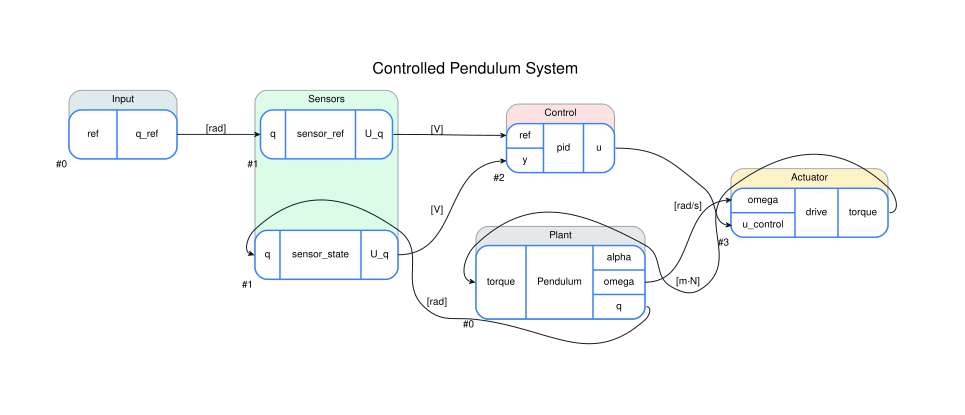

In [47]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("figures/demo-2-8_syssimx_system_graph.svg")

**Setup Simulation Monitor**

In [48]:
system.initialize(t, t_end=t_end)
pendulum.setup_monitoring()
pendulum.display_monitoring()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [49]:
system.run(t, t_end, dt)

[Pendulum] Switching: OpenSim to FEM @ t=0.0900s
[Pendulum] Switching: FEM to EQB @ t=0.1700s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit de

In [50]:
t_vals_ref, q_vals_ref = zip(*ref.outputs['q_ref'].history)

if isinstance(pendulum, MasterPendulum):
    t_vals_eqb, q_vals_eqb = zip(*pendulum.models['EQB'].outputs['q'].history)
    t_vals_fem, q_vals_fem = zip(*pendulum.models['FEM'].outputs['q'].history)
    t_vals_os, q_vals_os = zip(*pendulum.models['OpenSim'].outputs['q'].history)

    _, omega_vals_eqb = zip(*pendulum.models['EQB'].outputs['omega'].history)
    _, omega_vals_fem = zip(*pendulum.models['FEM'].outputs['omega'].history)
    _, omega_vals_os = zip(*pendulum.models['OpenSim'].outputs['omega'].history)

    _, alpha_vals_eqb = zip(*pendulum.models['EQB'].outputs['alpha'].history)
    _, alpha_vals_fem = zip(*pendulum.models['FEM'].outputs['alpha'].history)
    _, alpha_vals_os = zip(*pendulum.models['OpenSim'].outputs['alpha'].history)

    omega_vals_eqb = [val.magnitude for val in omega_vals_eqb]
    omega_vals_fem = [val.magnitude for val in omega_vals_fem]
    omega_vals_os = [val.magnitude for val in omega_vals_os]

    alpha_vals_eqb = [val.magnitude for val in alpha_vals_eqb]
    alpha_vals_fem = [val.magnitude for val in alpha_vals_fem]
    alpha_vals_os = [val.magnitude for val in alpha_vals_os]

if isinstance(pendulum, FMUComponent):
    t_vals_eqb, q_vals_eqb = zip(*pendulum.outputs['q'].history)
    _, omega_vals_eqb = zip(*pendulum.outputs['omega'].history)
    _, alpha_vals_eqb = zip(*pendulum.outputs['alpha'].history)
    omega_vals_eqb = [val.magnitude for val in omega_vals_eqb]
    alpha_vals_eqb = [val.magnitude for val in alpha_vals_eqb]

t_drive, torque_drive_vals = zip(*drive.outputs['torque'].history)
torque_drive_vals = [val.magnitude for val in torque_drive_vals]

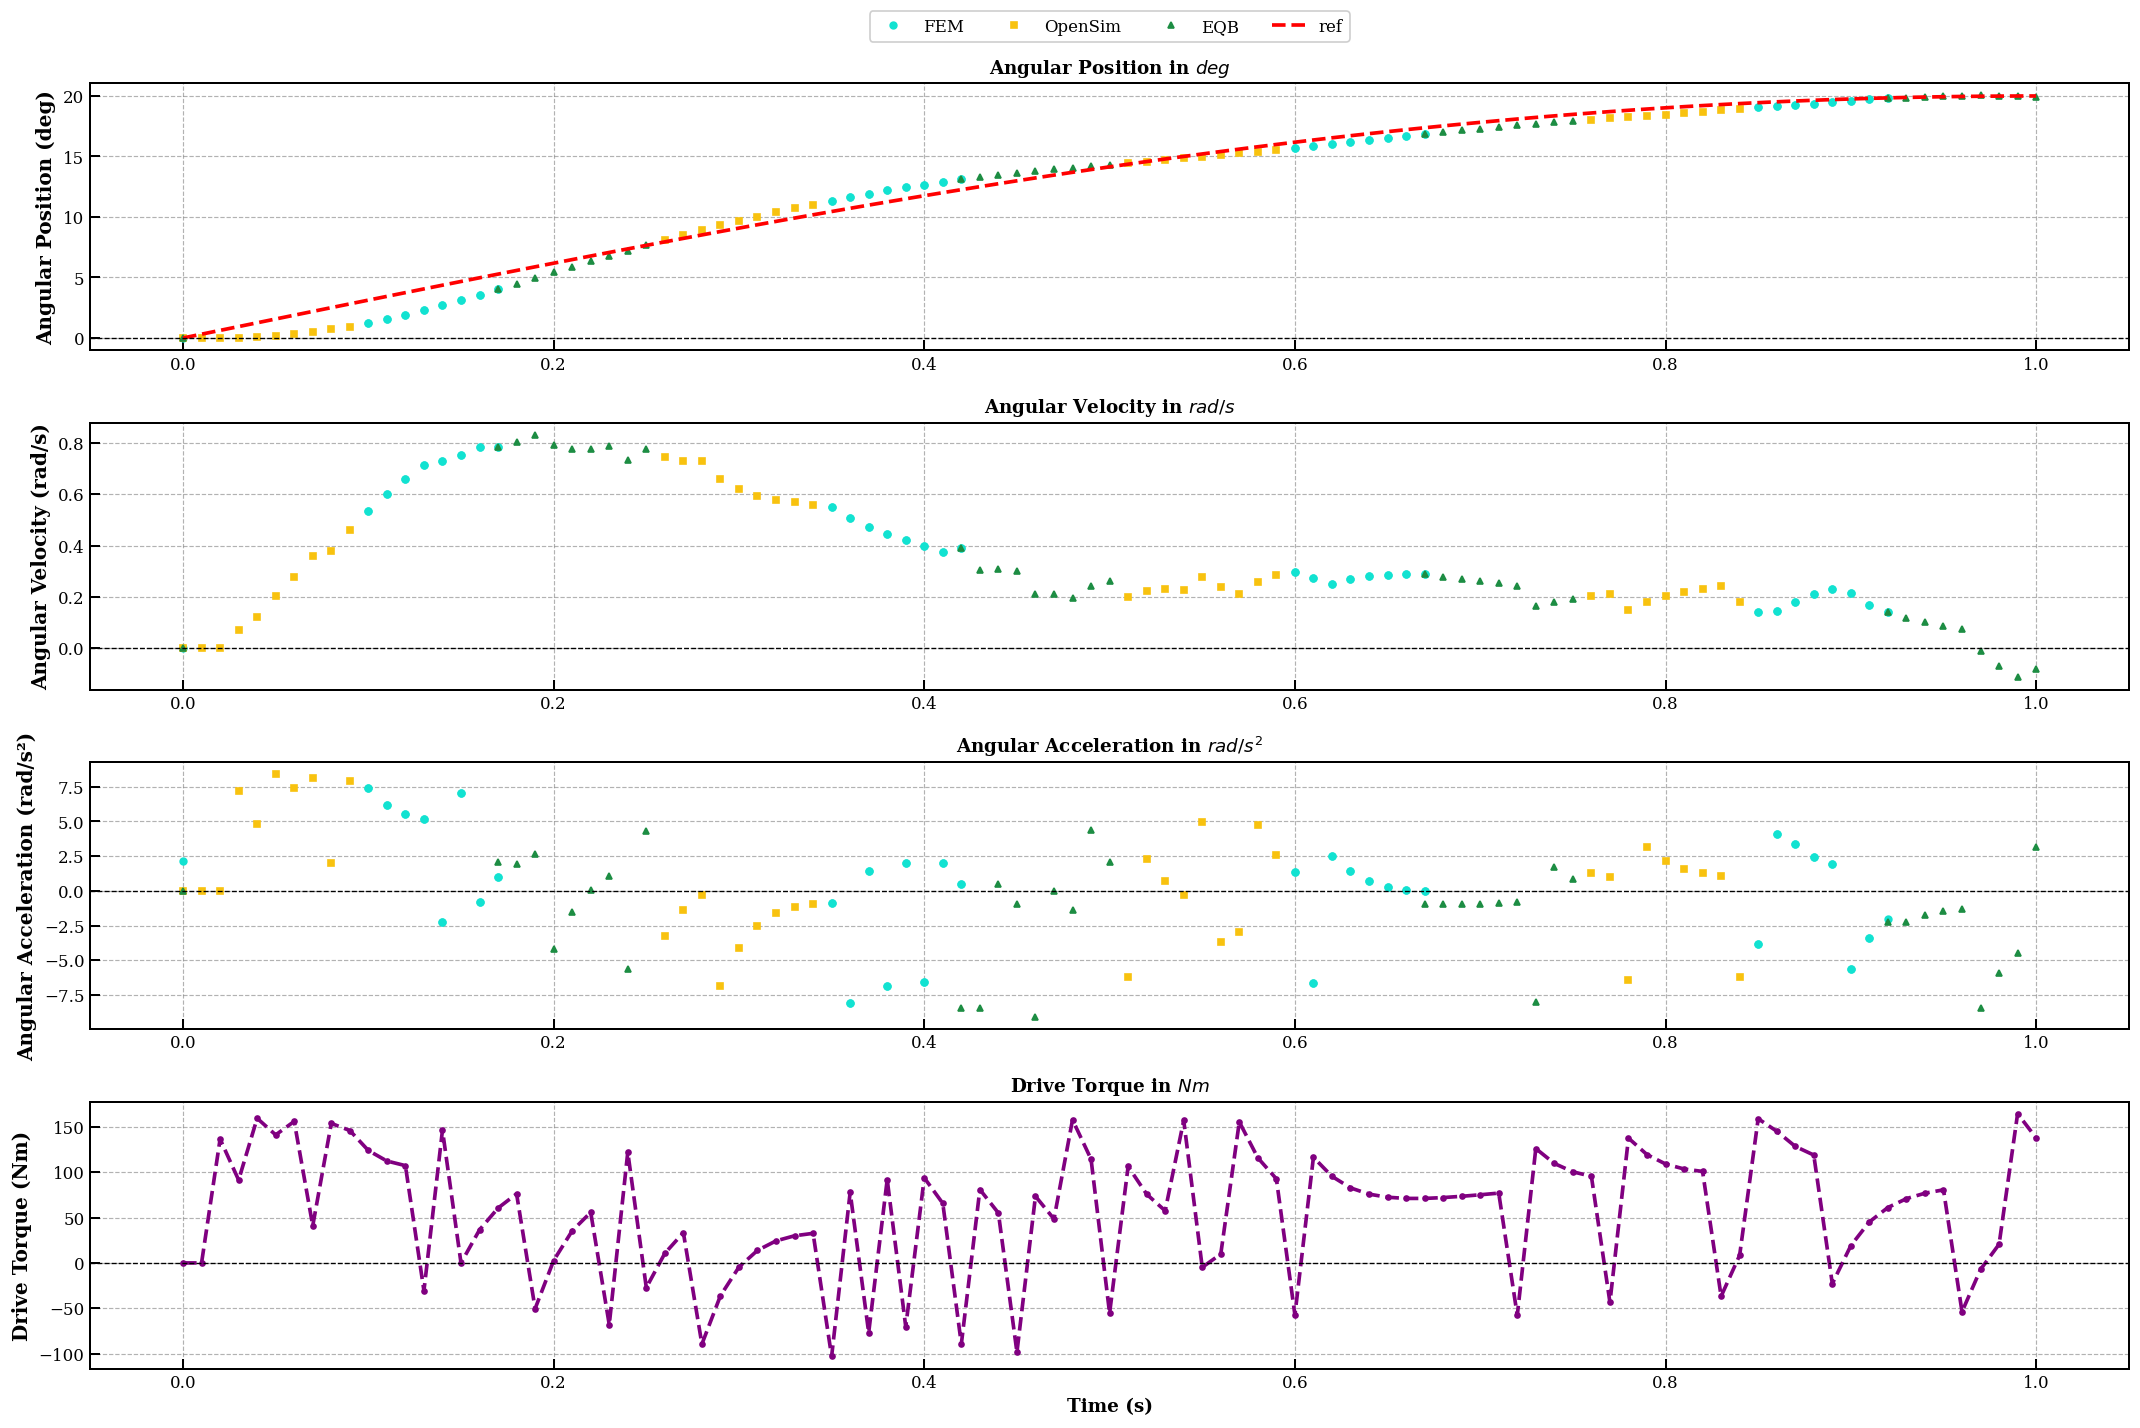

In [51]:
marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  # Deep blue
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5}  # Green
eqb_style = {'color': "#1d8d43", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}  # Purple
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(18, 12))

plt.subplot(4,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals_fem, np.rad2deg(q_vals_fem), label="FEM", **fem_style)
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, np.rad2deg(q_vals_eqb), label="EQB", **eqb_style)
plt.plot(t_vals_ref, np.rad2deg(q_vals_ref), label="ref", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)", fontweight='bold')
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)


plt.subplot(4,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals_fem, omega_vals_fem, label="FEM", **fem_style)
plt.plot(t_vals_os, omega_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, omega_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)", fontweight='bold')
plt.grid(which='both')

plt.subplot(4,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals_fem[:-1], alpha_vals_fem[:-1], label="FEM", **fem_style)
plt.plot(t_vals_os, alpha_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, alpha_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)", fontweight='bold')
plt.grid(which='both')

plt.subplot(4,1,4).set_title("Drive Torque in $Nm$", **fontdict)
plt.plot(t_drive, torque_drive_vals, label="Drive Torque", linestyle='--', marker='o', markersize=3, color='purple')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Drive Torque (Nm)", fontweight='bold')
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
plt.savefig("figures/ControlledPendulum.svg")
plt.show()